## Exploratory Data Analysis
Basic checks on the train and test data before building any model.

### 1. Imports

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

### 2. Loading the Datasets

Three files to work with:
- `train.csv` — labelled questions (2000 rows)
- `test.csv` — unlabeled questions (500 rows)
- `sample_submission.csv` — submission format

In [47]:
DATA_DIR = Path("../data")
TRAIN_CSV = DATA_DIR / "train.csv"
TEST_CSV = DATA_DIR / "test.csv"
SAMPLE_SUB_CSV = DATA_DIR / "sample_submission.csv"

In [48]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
sample_sub_df = pd.read_csv(SAMPLE_SUB_CSV)

### 3. Column Overview & Data Types

Quick look at what each file contains and the type of every column.

In [49]:
train_df.head(3)

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C


In [50]:
test_df.head(3)

,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...


In [51]:
train_df.tail(3)

,id,prompt,A,B,C,D,E,answer
1997,1998,Determine the correct option: What does Earnsh...,A collection of point charges can be maintaine...,A collection of point charges can be maintaine...,A collection of point charges can be maintaine...,A collection of point charges cannot be mainta...,A collection of point charges can be maintaine...,D
1998,1999,Identify the correct statement: What is the re...,The atmosphere is a mechanism that is only inf...,"The atmosphere possesses both chaos and order,...",The atmosphere is a structure that is only inf...,The atmosphere is a completely chaotic mechani...,The atmosphere is a completely ordered structu...,B
1999,2000,Pick the best possible answer: Which of the fo...,Gravitational waves have an amplitude denoted ...,Gravitational waves have an amplitude denoted ...,Gravitational waves have an amplitude denoted ...,Gravitational waves have an amplitude denoted ...,Gravitational waves have an amplitude denoted ...,C


In [52]:
print(f" Train shape: {train_df.shape}")

 Train shape: (2000, 8)


In [53]:
print(train_df.columns.tolist())

['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer']


In [54]:
print(f" Test shape: {test_df.shape}")

 Test shape: (500, 7)


In [55]:
print(test_df.columns.tolist())

['id', 'prompt', 'A', 'B', 'C', 'D', 'E']


In [56]:
print(f" Sample Submission shape: {sample_sub_df.shape}")

 Sample Submission shape: (500, 2)


In [57]:
print(sample_sub_df.columns.tolist())

['ID', 'Prediction']


In [58]:
print(train_df.dtypes)

id        int64
prompt      str
A           str
B           str
C           str
D           str
E           str
answer      str
dtype: object


### 4. Data Quality Check

Checking for missing values and duplicate rows in both train and test sets.

In [59]:
missing_train = train_df.isnull().sum()
print(missing_train)

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64


In [60]:
missing_test = test_df.isnull().sum()
print(missing_test)

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
dtype: int64


In [61]:
# Check for duplicates
print(f"Train duplicates: {train_df.duplicated().sum()}")
print(f"Test duplicates: {test_df.duplicated().sum()}")

Train duplicates: 0
Test duplicates: 0


### 5. Sample Data Preview

Looking at the first couple of rows to understand how a question looks in the data.

In [62]:
# Show first row
print("\nROW 1:")
print(f"ID: {train_df.iloc[0]['id']}")
print(f"PROMPT: {train_df.iloc[0]['prompt'][:100]}...")
print(f"OPTION A: {train_df.iloc[0]['A'][:80]}...")
print(f"OPTION B: {train_df.iloc[0]['B'][:80]}...")
print(f"ANSWER: {train_df.iloc[0]['answer']}")



ROW 1:
ID: 1
PROMPT: Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and ...
OPTION A: Martin Heidegger believes that humans exist within a time continuum that is infi...
OPTION B: Martin Heidegger believes that humans do not exist inside time, but that they ar...
ANSWER: B


In [63]:
# Show second row
print("\nROW 2:")
print(f"ID: {train_df.iloc[1]['id']}")
print(f"PROMPT: {train_df.iloc[1]['prompt'][:100]}...")
print(f"OPTION A: {train_df.iloc[1]['A'][:80]}...")
print(f"OPTION B: {train_df.iloc[0]['B'][:80]}...")
print(f"ANSWER: {train_df.iloc[1]['answer']}")


ROW 2:
ID: 2
PROMPT: What is accelerator-based light-ion fusion?...
OPTION A: Accelerator-based light-ion fusion is a technique that uses particle accelerator...
OPTION B: Martin Heidegger believes that humans do not exist inside time, but that they ar...
ANSWER: A


### 6. Answer Distribution

Seeing how the labels are spread across A–E. Important to catch imbalance early.

In [64]:
answer_counts = train_df["answer"].value_counts()
answer_pct = (answer_counts / len(train_df) * 100).round(2)
print(answer_counts)
print(answer_pct)

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64
answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: count, dtype: float64


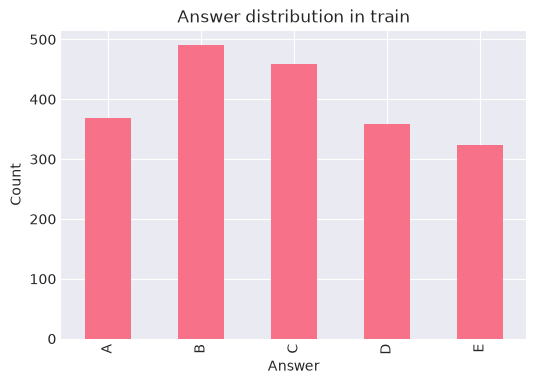

In [65]:
fig, ax = plt.subplots(figsize=(6,4))
answer_counts.sort_index().plot(kind="bar", ax=ax)
ax.set_title("Answer distribution in train")
ax.set_xlabel("Answer")
ax.set_ylabel("Count")
plt.show()

### 7. Duplicate prompts inside train
Same question text appearing more than once in train.csv.

In [66]:
dup_prompts = train_df["prompt"].duplicated().sum()
unique_prompts = train_df["prompt"].nunique()
print("unique prompts:", unique_prompts)
print("duplicate prompt rows:", dup_prompts)

unique prompts: 1758
duplicate prompt rows: 242


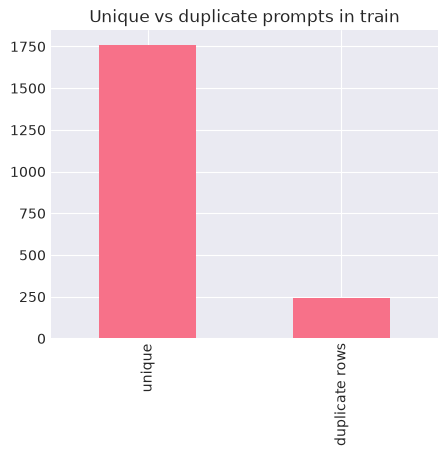

In [67]:
fig, ax = plt.subplots(figsize=(5,4))
pd.Series({"unique": unique_prompts, "duplicate rows": dup_prompts}).plot(kind="bar", ax=ax)
ax.set_title("Unique vs duplicate prompts in train")
plt.show()

### 8. Prompt overlap between train and test
How many test prompts also appear word-for-word in train.

In [68]:
overlap_prompts = set(train_df["prompt"]) & set(test_df["prompt"])
overlap_rows = test_df["prompt"].isin(overlap_prompts).sum()
print("shared prompts:", len(overlap_prompts))
print("test rows covered by overlap:", overlap_rows, "out of", len(test_df))

shared prompts: 267
test rows covered by overlap: 268 out of 500


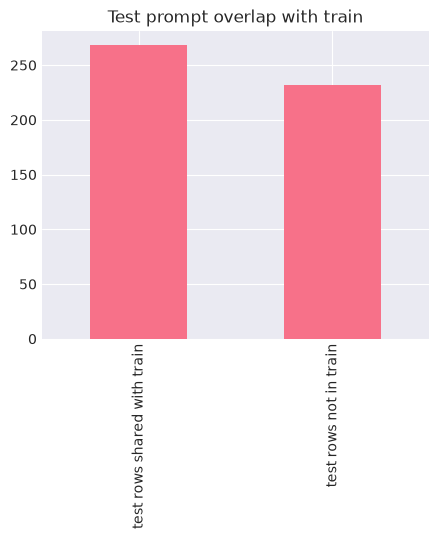

In [69]:
fig, ax = plt.subplots(figsize=(5,4))
pd.Series({"test rows shared with train": overlap_rows,
           "test rows not in train": len(test_df) - overlap_rows}).plot(kind="bar", ax=ax)
ax.set_title("Test prompt overlap with train")
plt.show()

### 9. Prompt length
Length of the question text, in characters and in words.

In [70]:
train_df["prompt_len"] = train_df["prompt"].str.len()
train_df["prompt_words"] = train_df["prompt"].str.split().str.len()
print(train_df["prompt_len"].describe())
print(train_df["prompt_words"].describe())

count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: prompt_len, dtype: float64
count    2000.00000
mean       18.14650
std         6.78189
min         3.00000
25%        14.00000
50%        17.00000
75%        22.00000
max        51.00000
Name: prompt_words, dtype: float64


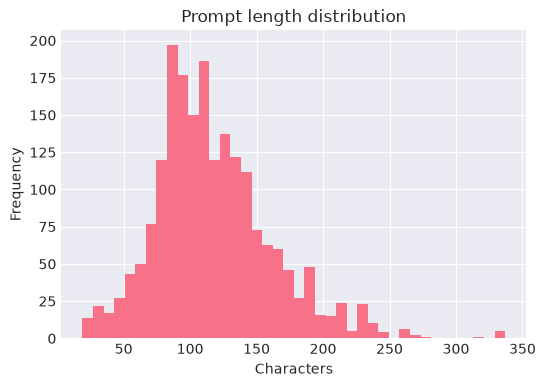

In [71]:
fig, ax = plt.subplots(figsize=(6,4))
train_df["prompt_len"].plot(kind="hist", bins=40, ax=ax)
ax.set_title("Prompt length distribution")
ax.set_xlabel("Characters")
plt.show()

### 10. Option length by letter
Average character length of options A through E, and how spread out they are.

In [72]:
option_cols = list("ABCDE")
avg_lens = {c: train_df[c].str.len().mean() for c in option_cols}
print(avg_lens)

{'A': np.float64(164.0915), 'B': np.float64(166.6165), 'C': np.float64(167.227), 'D': np.float64(162.5635), 'E': np.float64(164.23)}


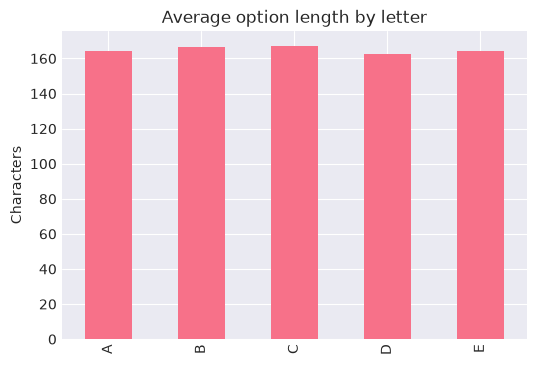

In [73]:
fig, ax = plt.subplots(figsize=(6,4))
pd.Series(avg_lens).plot(kind="bar", ax=ax)
ax.set_title("Average option length by letter")
ax.set_ylabel("Characters")
plt.show()

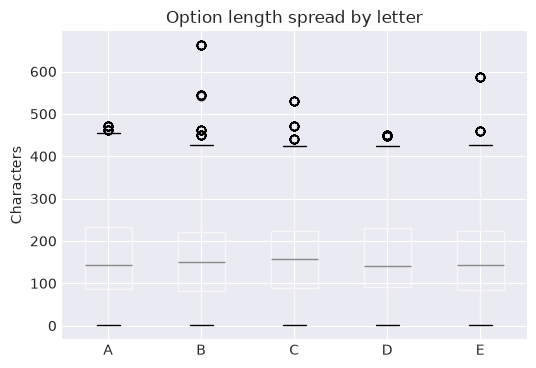

In [74]:
fig, ax = plt.subplots(figsize=(6,4))
train_df[option_cols].apply(lambda col: col.str.len()).boxplot(ax=ax)
ax.set_title("Option length spread by letter")
ax.set_ylabel("Characters")
plt.show()

### 11. One full sample question
Printing one row in full to see what the raw data actually looks like.

In [75]:
row = train_df.iloc[0]
print(row["prompt"])
for c in option_cols:
    print(c, ":", row[c])
print("answer:", row["answer"])

Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.
A : Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.
B : Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.
C : Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is solely based on the present.
D : Martin Heidegger believes that the relationship bet

### 12. Correct answer ka length-rank (kya lamba option hi zyada baar sahi hota hai)

answer_len_rank
1    811
2    497
3    279
4    189
5    224
Name: count, dtype: int64


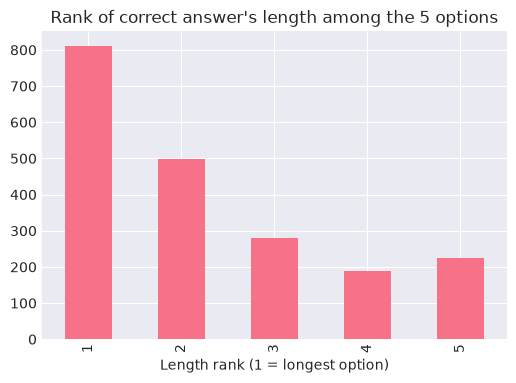

In [76]:
def length_rank(row):
    lens = {c: len(row[c]) for c in option_cols}
    ranked = sorted(lens, key=lens.get, reverse=True)
    return ranked.index(row['answer']) + 1

train_df['answer_len_rank'] = train_df.apply(length_rank, axis=1)
print(train_df['answer_len_rank'].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(6,4))
train_df['answer_len_rank'].value_counts().sort_index().plot(kind='bar', ax=ax)
ax.set_title("Rank of correct answer's length among the 5 options")
ax.set_xlabel("Length rank (1 = longest option)")
plt.show()

### 13. Question type — first word of each prompt

first_word
pick         316
select       309
identify     302
determine    299
which        293
choose       292
what         180
who            7
how            2
Name: count, dtype: int64


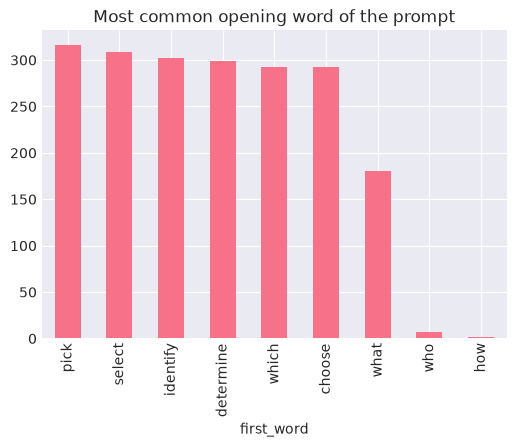

In [77]:
train_df['first_word'] = train_df['prompt'].str.split().str[0].str.lower()
print(train_df['first_word'].value_counts().head(10))

fig, ax = plt.subplots(figsize=(6,4))
train_df['first_word'].value_counts().head(10).plot(kind='bar', ax=ax)
ax.set_title("Most common opening word of the prompt")
plt.show()

### 14. Most frequent words across all prompts

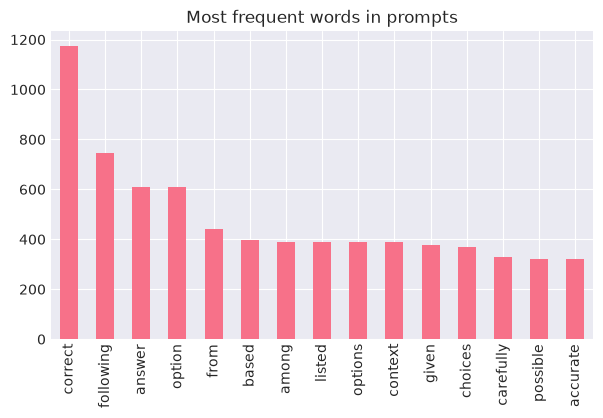

In [78]:
from collections import Counter

stopwords = set(['the','a','an','is','of','to','and','in','for','on','what','which','does','do','are','be'])
words = ' '.join(train_df['prompt'].str.lower()).split()
words = [w.strip('.,?:;') for w in words if w.strip('.,?:;') not in stopwords]
top_words = Counter(words).most_common(15)

fig, ax = plt.subplots(figsize=(7,4))
pd.Series(dict(top_words)).plot(kind='bar', ax=ax)
ax.set_title("Most frequent words in prompts")
plt.show()

### 15. Summary of this complete EDA is :

- Train has 2000 rows, test has 500 rows, 5 options per question (A-E)
- No missing values and no full-row duplicates in either file
- 242 prompt rows in train are duplicates of another prompt in train
- 267 prompts are shared word-for-word between train and test
- Answer distribution is not perfectly balanced, B and C appear more often than D and E
- Prompt length varies a lot, from under 20 characters to over 300